<a href="https://colab.research.google.com/github/MAYANK181105/Project2/blob/main/Mayank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv")
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [3]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
df.columns = df.columns.str.strip().str.lower()
df = df.loc[:, ~df.columns.str.startswith("unnamed")]
df["age_years"] = np.where(df["age"] <= 1, df["age"] * 100, df["age"]).round().astype(int)
df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,age_years
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no,19
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no,19
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no,19
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no,19
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no,19


In [4]:
df.tail()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,age_years
5185,0,female,0.22,0.55,0,0,0,no,no,no,no,no,22
5186,0,male,0.27,1.30,0,0,1,no,no,no,no,no,27
5187,0,female,0.37,0.25,1,0,1,no,no,yes,no,no,37
5188,0,female,0.52,0.65,0,0,0,no,no,no,no,no,52
5189,0,male,0.72,0.25,0,0,0,no,no,yes,no,no,72


In [5]:
df.shape

(5190, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object 
 11  lchronic   5190 non-null   object 
 12  age_years  5190 non-null   int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [7]:
df.describe()

,visits,age,income,illness,reduced,health,age_years
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534,40.638536
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266,20.478182
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000,19.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000,22.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000,32.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000,62.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000,72.000000


In [8]:
df.isnull().sum()

,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0
freerepat,0


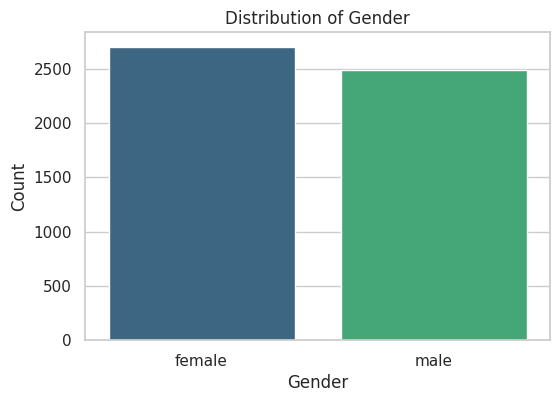

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

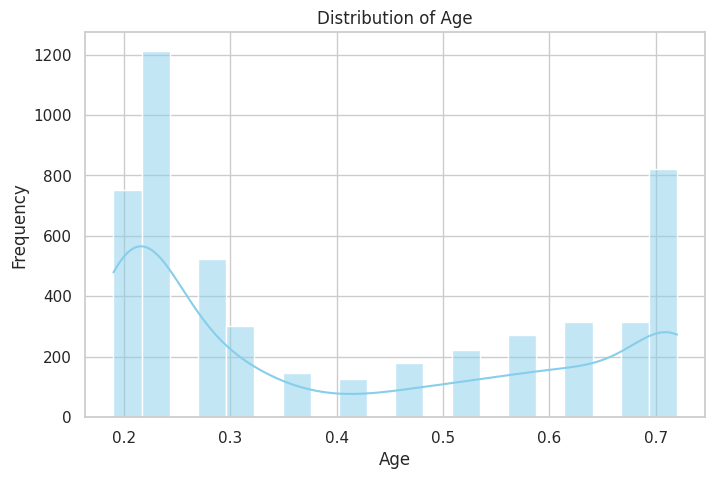

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

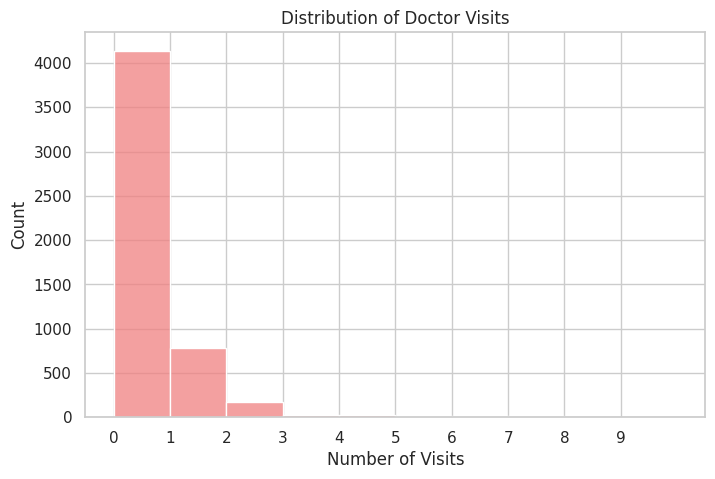

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['visits'], bins=range(int(df['visits'].max()) + 2), kde=False, color='lightcoral', stat='count')
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.xticks(range(int(df['visits'].max()) + 1))
plt.show()

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


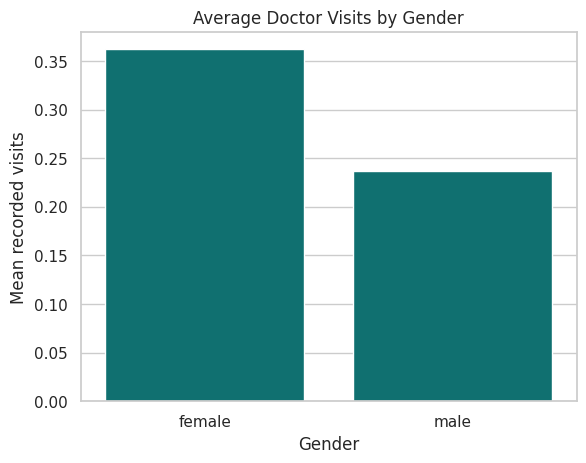

In [12]:
gender_analysis = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)
display(gender_analysis)
sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)
plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


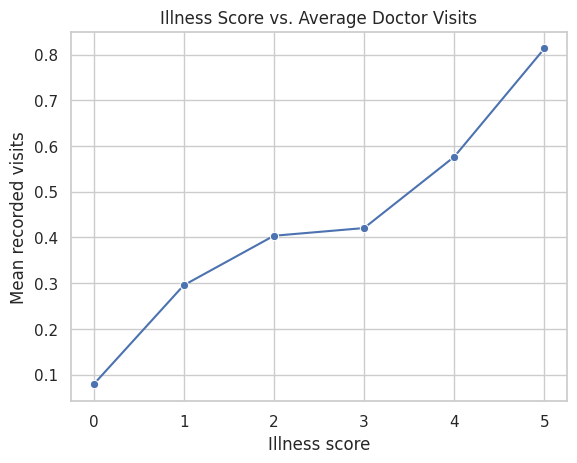

In [13]:
illness_analysis = (
    df.groupby("illness")["visits"]
      .agg(["count", "mean"])
      .reset_index()
)
display(illness_analysis)
sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)
plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

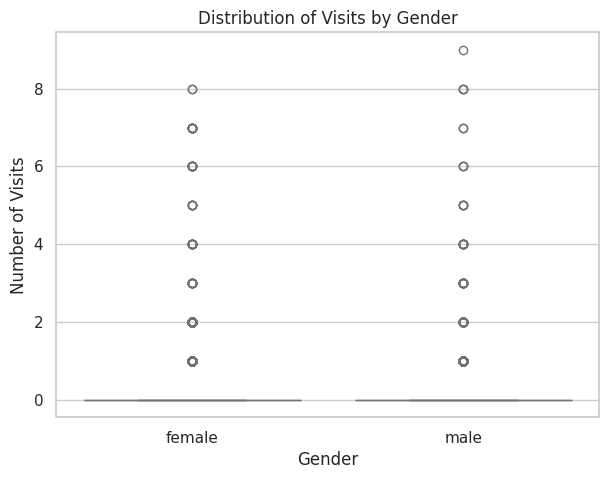

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='gender', y='visits', data=df, palette='pastel', hue='gender', legend=False)
plt.title('Distribution of Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Visits')
plt.show()

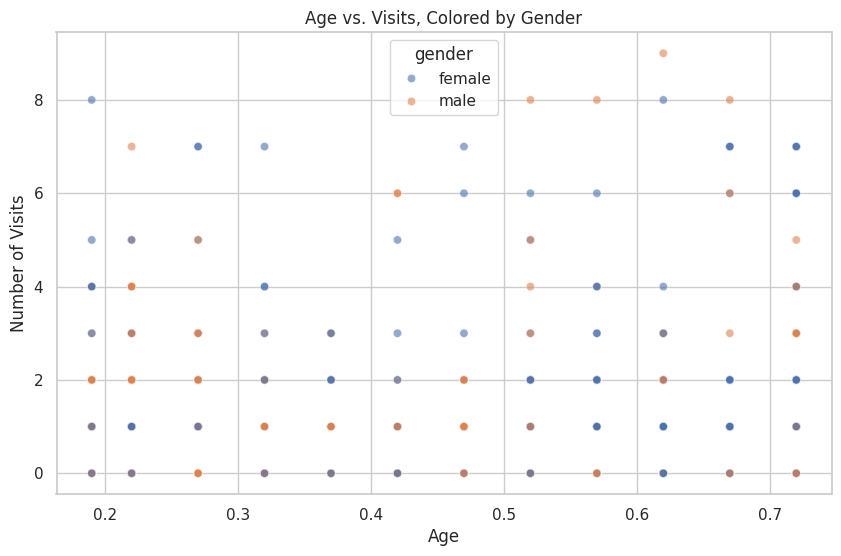

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='visits', hue='gender', data=df, palette='deep', alpha=0.6)
plt.title('Age vs. Visits, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()

In [16]:
num_cols = ["visits", "age_years", "income", "illness", "reduced", "health"]
bin_cols = ["private", "freepoor", "freerepat", "nchronic", "lchronic"]
summary = df[num_cols].describe().T
summary["skew"] = df[num_cols].skew()
print(summary.round(2).to_string())
flag_pct = df[bin_cols].apply(lambda s: (s == "yes").mean() * 100).round(1)
print("\n% of patients with each flag = yes:")
print(flag_pct.to_string())

            count   mean    std   min    25%    50%   75%   max  skew
visits     5190.0   0.30   0.80   0.0   0.00   0.00   0.0   9.0  4.74
age_years  5190.0  40.64  20.48  19.0  22.00  32.00  62.0  72.0  0.42
income     5190.0   0.58   0.37   0.0   0.25   0.55   0.9   1.5  0.73
illness    5190.0   1.43   1.38   0.0   0.00   1.00   2.0   5.0  0.94
reduced    5190.0   0.86   2.89   0.0   0.00   0.00   0.0  14.0  3.83
health     5190.0   1.22   2.12   0.0   0.00   0.00   2.0  12.0  2.40

% of patients with each flag = yes:
private      44.3
freepoor      4.3
freerepat    21.0
nchronic     40.3
lchronic     11.7


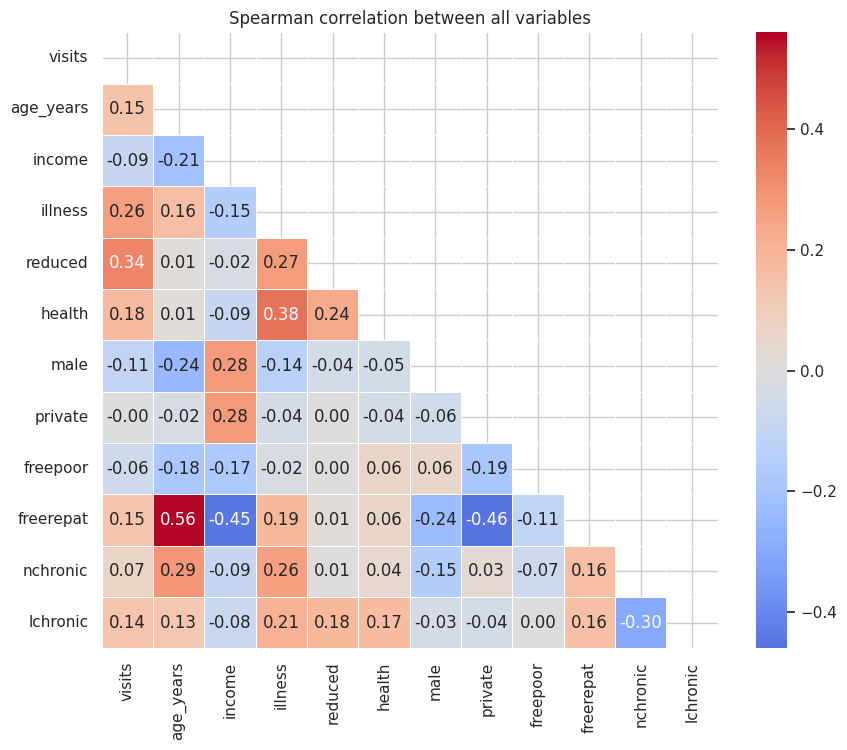

In [17]:
enc = df.copy()
for c in bin_cols:
    enc[c] = (enc[c] == "yes").astype(int)
enc["male"] = (enc["gender"] == "male").astype(int)

corr_cols = ["visits", "age_years", "income", "illness", "reduced", "health", "male"] + bin_cols
corr = enc[corr_cols].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True,
            fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=.5)
plt.title("Spearman correlation between all variables")
plt.show()

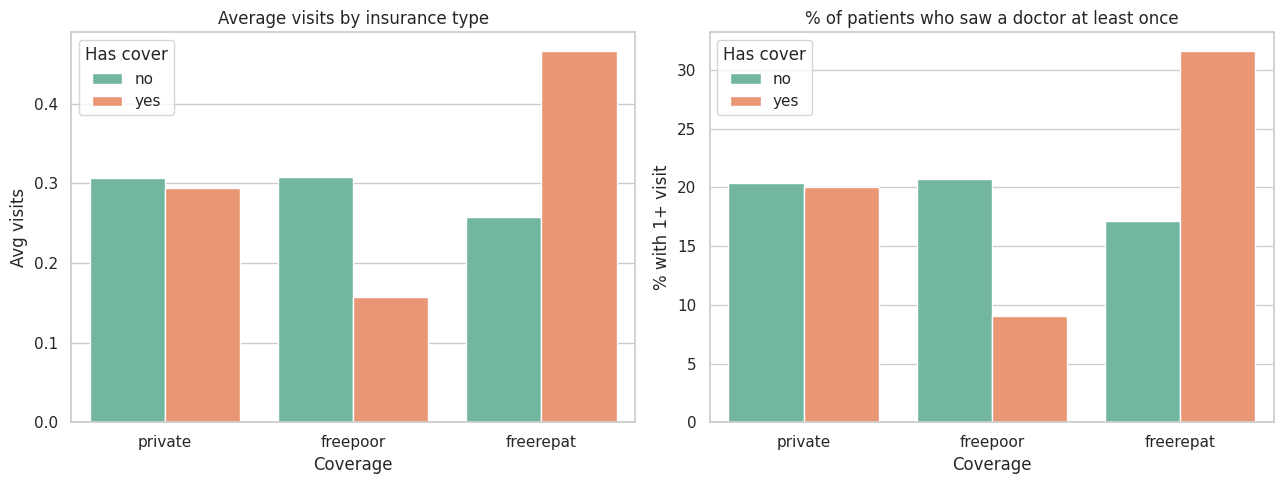

In [18]:
rows = []
for c in ["private", "freepoor", "freerepat"]:
    for level, g in df.groupby(c):
        rows.append({"Coverage": c, "Has cover": level,
                     "Avg visits": g["visits"].mean(),
                     "% with 1+ visit": (g["visits"] > 0).mean() * 100})
ins = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=ins, x="Coverage", y="Avg visits", hue="Has cover", ax=axes[0], palette="Set2")
axes[0].set_title("Average visits by insurance type")
sns.barplot(data=ins, x="Coverage", y="% with 1+ visit", hue="Has cover", ax=axes[1], palette="Set2")
axes[1].set_title("% of patients who saw a doctor at least once")
plt.tight_layout()
plt.show()

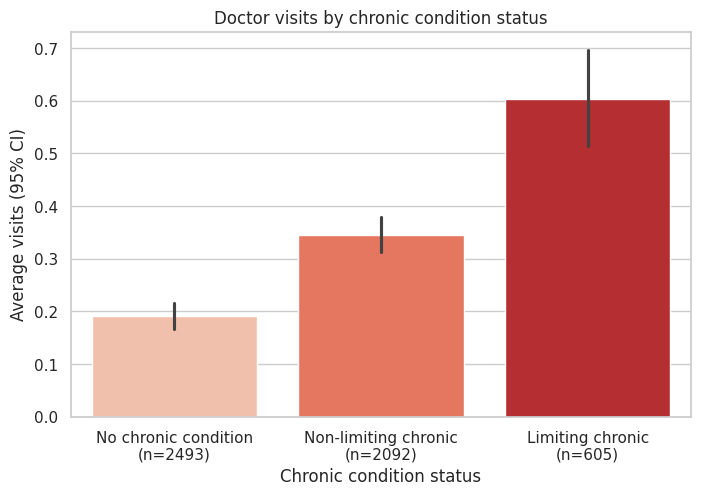

In [19]:
df["chronic_status"] = np.select(
    [df.lchronic == "yes", df.nchronic == "yes"],
    ["Limiting chronic", "Non-limiting chronic"],
    default="No chronic condition")
order = ["No chronic condition", "Non-limiting chronic", "Limiting chronic"]

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df, x="chronic_status", y="visits", order=order,
                 hue="chronic_status", hue_order=order, palette="Reds", legend=False,
                 errorbar=("ci", 95))
counts = df["chronic_status"].value_counts()
ax.set_xticks(range(len(order)))
ax.set_xticklabels([f"{o}\n(n={counts[o]})" for o in order])
ax.set_xlabel("Chronic condition status")
ax.set_ylabel("Average visits (95% CI)")
ax.set_title("Doctor visits by chronic condition status")
plt.show()

                       avg_visits  avg_illness  patients
income_band                                             
Lowest (<=0.25)             0.398        1.744      1638
Lower-mid (0.26-0.55)       0.305        1.469      1329
Upper-mid (0.56-0.90)       0.230        1.197      1485
Highest (>0.90)             0.225        1.146       738


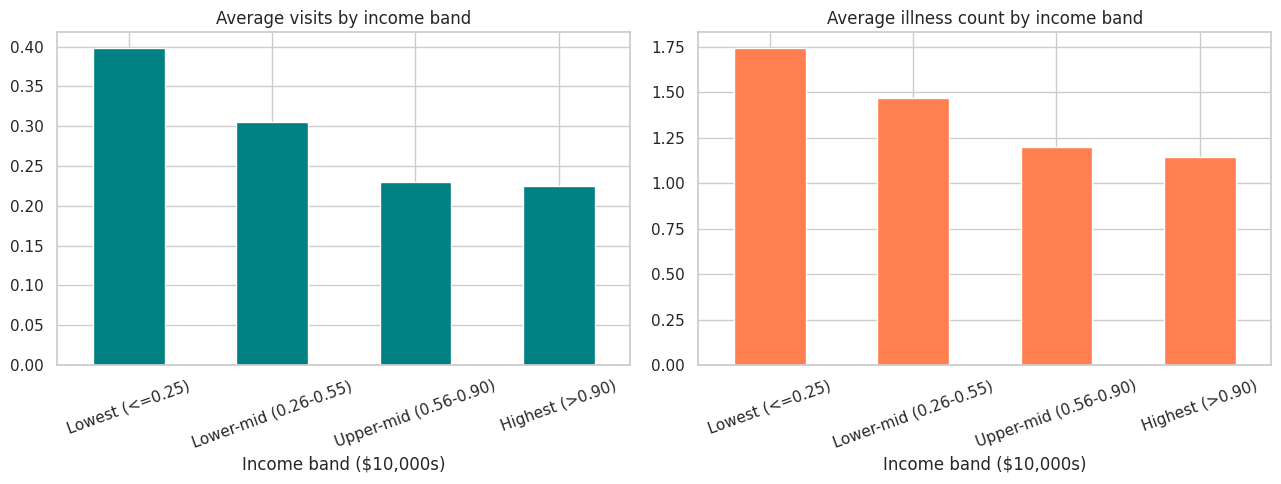

In [20]:
bins = [-0.01, 0.25, 0.55, 0.90, 1.6]
labels = ["Lowest (<=0.25)", "Lower-mid (0.26-0.55)", "Upper-mid (0.56-0.90)", "Highest (>0.90)"]
df["income_band"] = pd.cut(df["income"], bins=bins, labels=labels)

inc = df.groupby("income_band", observed=True).agg(avg_visits=("visits", "mean"),
                                                   avg_illness=("illness", "mean"),
                                                   patients=("visits", "size"))
print(inc.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
inc["avg_visits"].plot(kind="bar", ax=axes[0], color="teal", rot=20)
axes[0].set_title("Average visits by income band")
axes[0].set_xlabel("Income band ($10,000s)")
inc["avg_illness"].plot(kind="bar", ax=axes[1], color="coral", rot=20)
axes[1].set_title("Average illness count by income band")
axes[1].set_xlabel("Income band ($10,000s)")
plt.tight_layout()
plt.show()

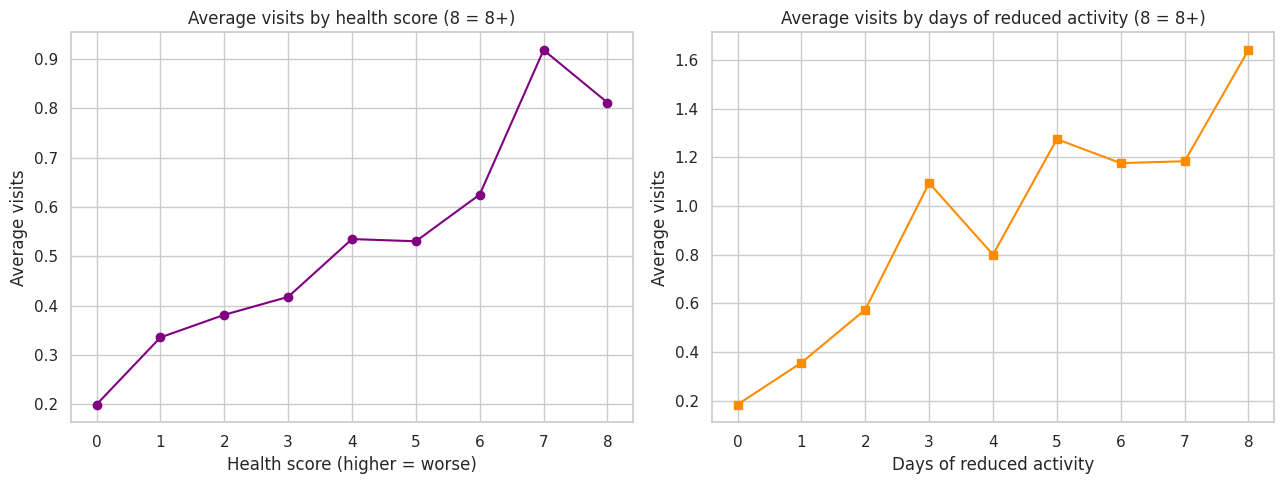

In [21]:
health_cap = df["health"].clip(upper=8)
reduced_cap = df["reduced"].clip(upper=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df.groupby(health_cap)["visits"].mean().plot(marker="o", ax=axes[0], color="purple")
axes[0].set_title("Average visits by health score (8 = 8+)")
axes[0].set_xlabel("Health score (higher = worse)")
axes[0].set_ylabel("Average visits")

df.groupby(reduced_cap)["visits"].mean().plot(marker="s", ax=axes[1], color="darkorange")
axes[1].set_title("Average visits by days of reduced activity (8 = 8+)")
axes[1].set_xlabel("Days of reduced activity")
axes[1].set_ylabel("Average visits")
plt.tight_layout()
plt.show()

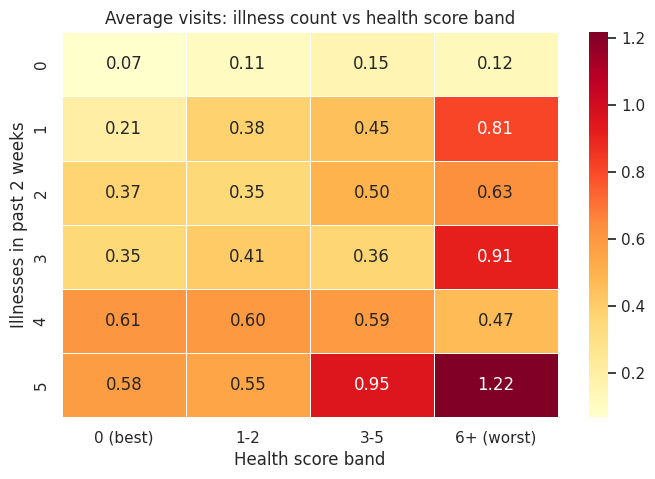

In [22]:
df["health_band"] = pd.cut(df["health"], [-1, 0, 2, 5, 12], labels=["0 (best)", "1-2", "3-5", "6+ (worst)"])
pivot = df.pivot_table(index="illness", columns="health_band", values="visits",
                       aggfunc="mean", observed=True)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=.5)
plt.title("Average visits: illness count vs health score band")
plt.ylabel("Illnesses in past 2 weeks")
plt.xlabel("Health score band")
plt.show()

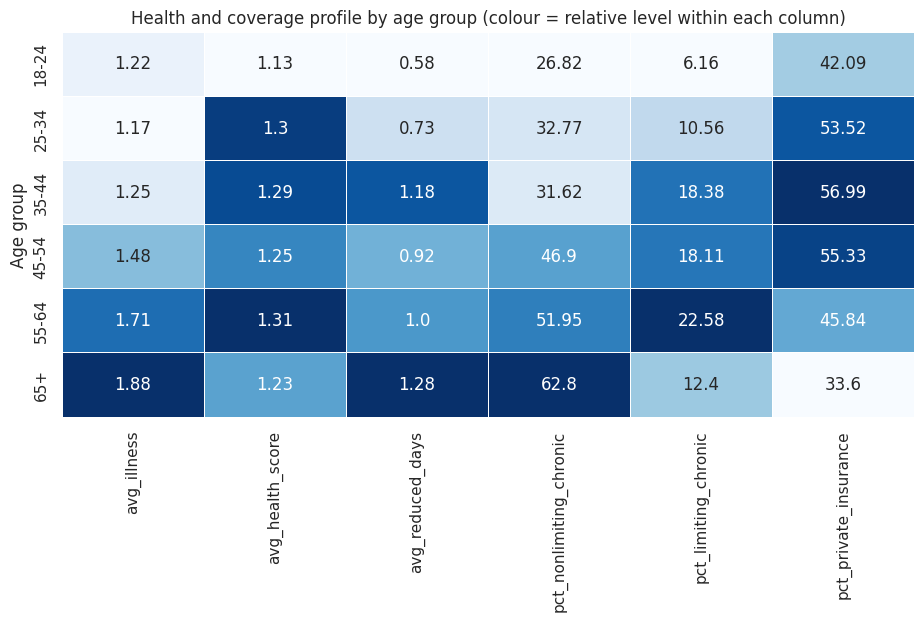

In [23]:
df["age_group"] = pd.cut(df["age_years"], [17, 24, 34, 44, 54, 64, 80],
                         labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"])
enc["age_group"] = df["age_group"]

profile = enc.groupby("age_group", observed=True).agg(
    avg_illness=("illness", "mean"),
    avg_health_score=("health", "mean"),
    avg_reduced_days=("reduced", "mean"),
    pct_nonlimiting_chronic=("nchronic", lambda s: s.mean() * 100),
    pct_limiting_chronic=("lchronic", lambda s: s.mean() * 100),
    pct_private_insurance=("private", lambda s: s.mean() * 100),
)
scaled = (profile - profile.min()) / (profile.max() - profile.min())
plt.figure(figsize=(11, 5))
sns.heatmap(scaled, annot=profile.round(2), fmt="", cmap="Blues", cbar=False, linewidths=.5)
plt.title("Health and coverage profile by age group (colour = relative level within each column)")
plt.ylabel("Age group")
plt.show()

In [24]:
enc["high_user"] = np.where(df["visits"] >= 3, "High (3+ visits)", "Others")

share_patients = (df["visits"] >= 3).mean() * 100
share_visits = df.loc[df["visits"] >= 3, "visits"].sum() / df["visits"].sum() * 100
print(f"High utilisers are {share_patients:.1f}% of patients but account for {share_visits:.1f}% of all visits.\n")

prof_cols = ["age_years", "income", "illness", "reduced", "health", "male"] + bin_cols
comp = enc.groupby("high_user")[prof_cols].mean().T
comp["ratio (high / others)"] = comp["High (3+ visits)"] / comp["Others"]
print(comp.round(2).sort_values("ratio (high / others)", ascending=False).to_string())

High utilisers are 1.8% of patients but account for 27.8% of all visits.

high_user  High (3+ visits)  Others  ratio (high / others)
reduced                7.75    0.74                  10.53
lchronic               0.30    0.11                   2.66
health                 3.06    1.18                   2.59
illness                2.42    1.41                   1.71
freerepat              0.28    0.21                   1.34
age_years             46.98   40.52                   1.16
nchronic               0.45    0.40                   1.12
male                   0.44    0.48                   0.92
income                 0.50    0.58                   0.85
private                0.38    0.44                   0.85
freepoor               0.03    0.04                   0.75


variable  lower fence  upper fence  outliers  % of rows
  income        -0.73         1.88         0       0.00
 reduced         0.00         0.00       736      14.18
  health        -3.00         5.00       303       5.84
 illness        -3.00         5.00         0       0.00


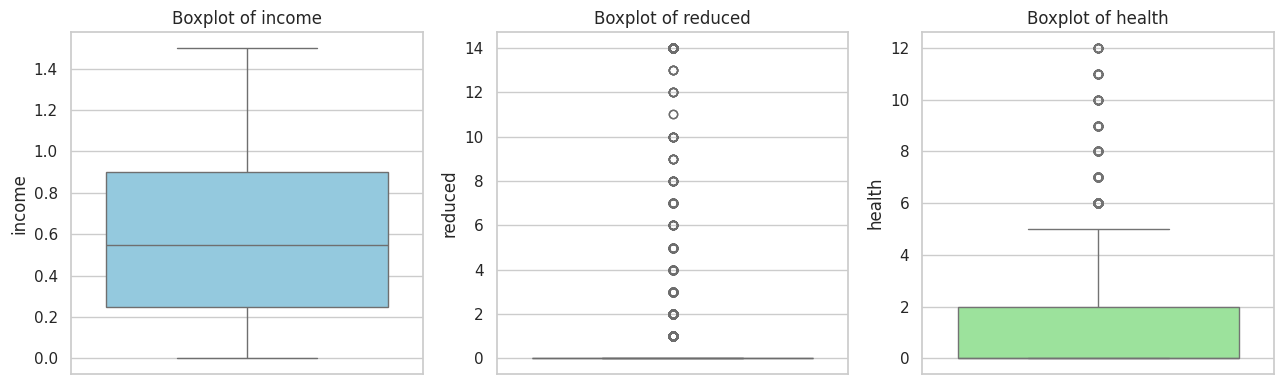

In [25]:
out_rows = []
for c in ["income", "reduced", "health", "illness"]:
    q1, q3 = df[c].quantile([.25, .75])
    iqr = q3 - q1
    n_out = ((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum()
    out_rows.append({"variable": c, "lower fence": q1 - 1.5 * iqr, "upper fence": q3 + 1.5 * iqr,
                     "outliers": n_out, "% of rows": n_out / len(df) * 100})
print(pd.DataFrame(out_rows).round(2).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c, col in zip(axes, ["income", "reduced", "health"], ["skyblue", "salmon", "lightgreen"]):
    sns.boxplot(y=df[c], ax=ax, color=col)
    ax.set_title(f"Boxplot of {c}")
plt.tight_layout()
plt.show()

 variable  diff in avg visits (yes - no)  CI low  CI high permutation p significant (5%)
  private                         -0.013  -0.053    0.031        0.5765               No
 freepoor                         -0.151  -0.235   -0.047        0.0105              Yes
freerepat                          0.209   0.151    0.273       <0.0005              Yes
 nchronic                          0.073   0.029    0.118        0.0005              Yes
 lchronic                          0.341   0.248    0.439       <0.0005              Yes


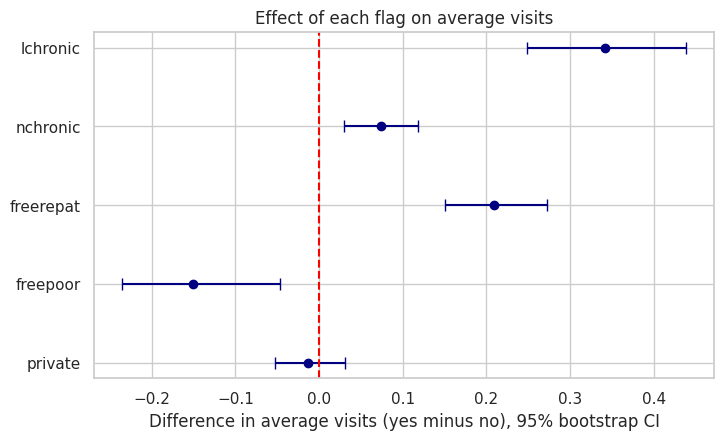

In [26]:
rng = np.random.default_rng(42)
n_boot = 2000
res = []

for c in bin_cols:
    yes = df.loc[df[c] == "yes", "visits"].to_numpy()
    no = df.loc[df[c] == "no", "visits"].to_numpy()
    observed = yes.mean() - no.mean()
    boot = np.array([rng.choice(yes, len(yes)).mean() - rng.choice(no, len(no)).mean()
                     for _ in range(n_boot)])
    low, high = np.percentile(boot, [2.5, 97.5])
    pooled = np.concatenate([yes, no])
    perm = np.empty(n_boot)
    for i in range(n_boot):
        rng.shuffle(pooled)
        perm[i] = pooled[:len(yes)].mean() - pooled[len(yes):].mean()
    p = (np.abs(perm) >= abs(observed)).mean()

    res.append({"variable": c, "diff in avg visits (yes - no)": observed,
                "CI low": low, "CI high": high,
                "permutation p": "<0.0005" if p == 0 else round(p, 4),
                "significant (5%)": "Yes" if (low > 0 or high < 0) else "No"})

res = pd.DataFrame(res)
print(res.round(3).to_string(index=False))

plt.figure(figsize=(8, 4.5))
plt.errorbar(res["diff in avg visits (yes - no)"], range(len(res)),
             xerr=[res["diff in avg visits (yes - no)"] - res["CI low"],
                   res["CI high"] - res["diff in avg visits (yes - no)"]],
             fmt="o", color="navy", capsize=4)
plt.axvline(0, color="red", ls="--")
plt.yticks(range(len(res)), res["variable"])
plt.xlabel("Difference in average visits (yes minus no), 95% bootstrap CI")
plt.title("Effect of each flag on average visits")
plt.show()

Dispersion factor: 1.33

             IRR  CI low  CI high significant (5%)
freepoor   0.915   0.843    0.993              Yes
male       0.925   0.868    0.985              Yes
income     0.933   0.869    1.002               No
freerepat  1.035   0.951    1.126               No
lchronic   1.050   0.989    1.114               No
age_years  1.059   0.981    1.143               No
nchronic   1.059   0.984    1.140               No
private    1.065   0.983    1.154               No
health     1.067   1.017    1.120              Yes
illness    1.294   1.222    1.370              Yes
reduced    1.442   1.395    1.490              Yes


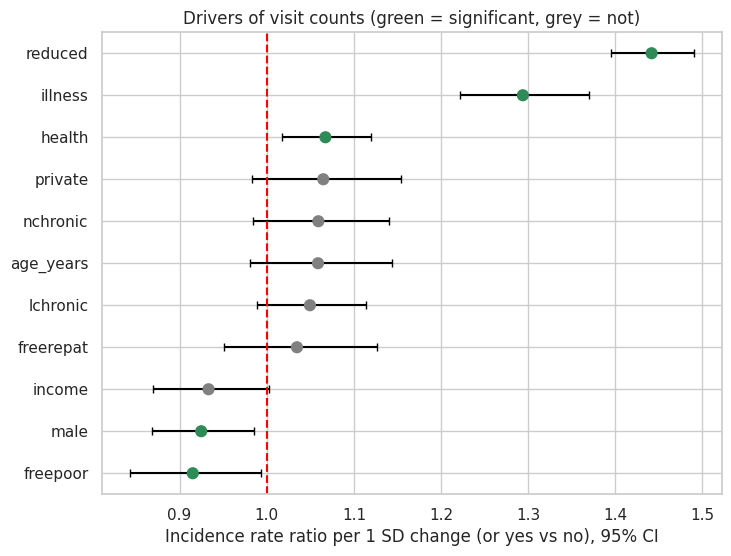

In [27]:
feat_cols = ["age_years", "income", "illness", "reduced", "health", "male"] + bin_cols
X = enc[feat_cols].astype(float)
Xs = (X - X.mean()) / X.std()
A = np.column_stack([np.ones(len(Xs)), Xs.to_numpy()])
y = df["visits"].to_numpy(dtype=float)
beta = np.zeros(A.shape[1])
beta[0] = np.log(y.mean())
for _ in range(100):
    mu = np.exp(A @ beta)
    z = A @ beta + (y - mu) / mu
    new_beta = np.linalg.solve(A.T @ (A * mu[:, None]), A.T @ (mu * z))
    converged = np.max(np.abs(new_beta - beta)) < 1e-8
    beta = new_beta
    if converged:
        break

mu = np.exp(A @ beta)
cov = np.linalg.inv(A.T @ (A * mu[:, None]))
dispersion = np.sum((y - mu) ** 2 / mu) / (len(y) - A.shape[1])
se = np.sqrt(np.diag(cov) * dispersion)

out = pd.DataFrame({"IRR": np.exp(beta[1:]),
                    "CI low": np.exp(beta[1:] - 1.96 * se[1:]),
                    "CI high": np.exp(beta[1:] + 1.96 * se[1:])}, index=feat_cols)
out["significant (5%)"] = np.where((out["CI low"] > 1) | (out["CI high"] < 1), "Yes", "No")
out = out.sort_values("IRR")
print(f"Dispersion factor: {dispersion:.2f}\n")
print(out.round(3).to_string())

plt.figure(figsize=(8, 6))
colors = np.where(out["significant (5%)"] == "Yes", "seagreen", "grey")
plt.errorbar(out["IRR"], range(len(out)),
             xerr=[out["IRR"] - out["CI low"], out["CI high"] - out["IRR"]],
             fmt="none", ecolor="black", capsize=3)
plt.scatter(out["IRR"], range(len(out)), c=colors, s=60, zorder=3)
plt.axvline(1, color="red", ls="--")
plt.yticks(range(len(out)), out.index)
plt.xlabel("Incidence rate ratio per 1 SD change (or yes vs no), 95% CI")
plt.title("Drivers of visit counts (green = significant, grey = not)")
plt.show()

            patients  avg_visits  pct_visited
risk_score                                   
0               1690        0.09         7.69
1               1541        0.22        16.03
2               1244        0.40        28.54
3                563        0.66        40.85
4                152        1.43        57.24


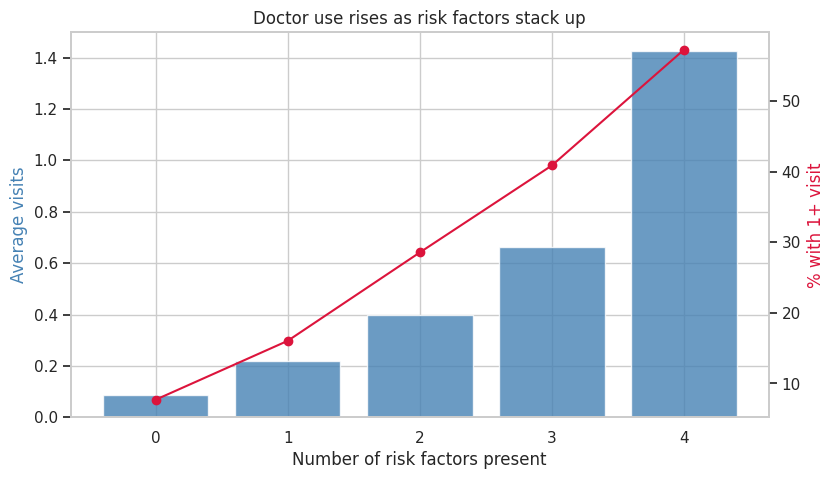

In [28]:
risk_flags = pd.DataFrame({
    "2+ illnesses": df["illness"] >= 2,
    "Health score 3+": df["health"] >= 3,
    "Any reduced-activity days": df["reduced"] >= 1,
    "Limiting chronic condition": df["lchronic"] == "yes",
    "Non-limiting chronic condition": df["nchronic"] == "yes",
})
df["risk_score"] = risk_flags.sum(axis=1)

risk = df.groupby("risk_score").agg(patients=("visits", "size"),
                                    avg_visits=("visits", "mean"),
                                    pct_visited=("visits", lambda s: (s > 0).mean() * 100))
print(risk.round(2).to_string())

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(risk.index, risk["avg_visits"], color="steelblue", alpha=.8)
ax1.set_xlabel("Number of risk factors present")
ax1.set_ylabel("Average visits", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(risk.index, risk["pct_visited"], color="crimson", marker="o")
ax2.set_ylabel("% with 1+ visit", color="crimson")
ax2.grid(False)
plt.title("Doctor use rises as risk factors stack up")
plt.show()